<a href="https://colab.research.google.com/github/ArshnoorSinghh/DSAI/blob/main/ML_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [4]:
df= pd.read_csv("insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#EDA

In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()  #for numeric values

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
# so step 1- descibe, info, isnull.sum,shape, head
#now eda visulatiztion


In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [13]:
numeric_cols=['age', 'bmi', 'children' ,'charges']

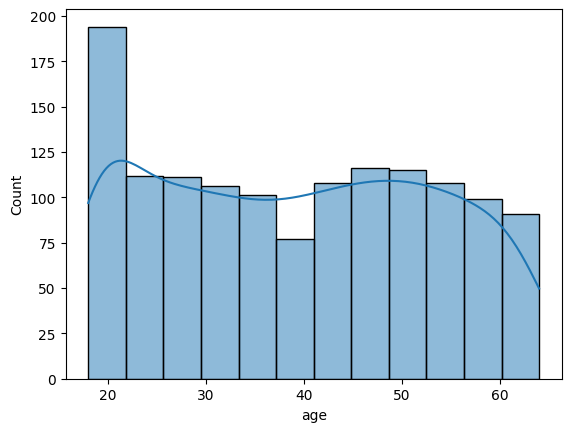

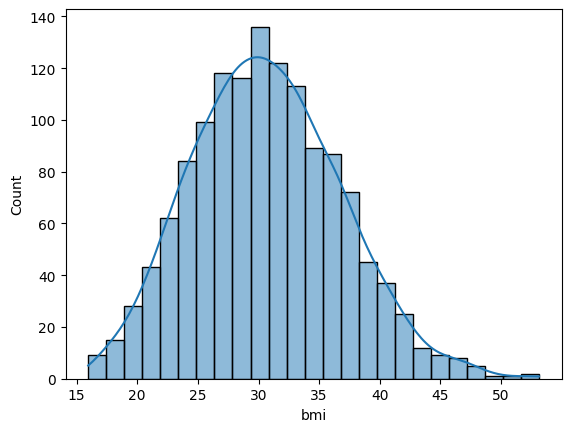

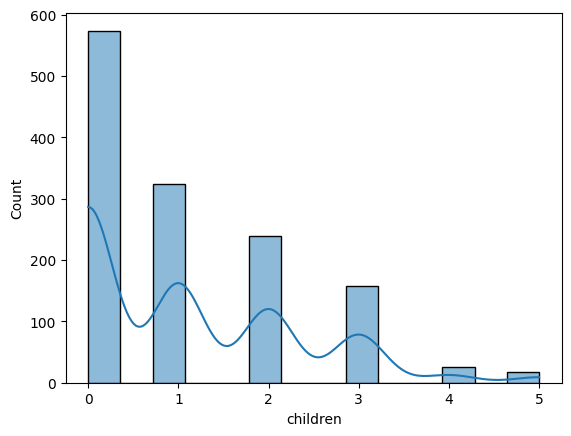

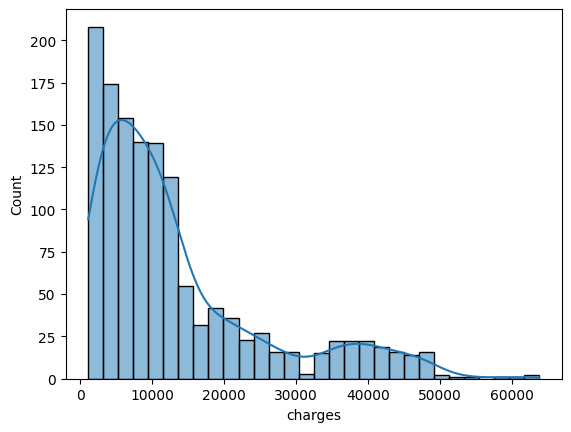

In [14]:
for cols in numeric_cols:
  plt.figure() # to get sep fig for all cols
  sns.histplot(df[cols], kde=True)

<Axes: xlabel='children', ylabel='count'>

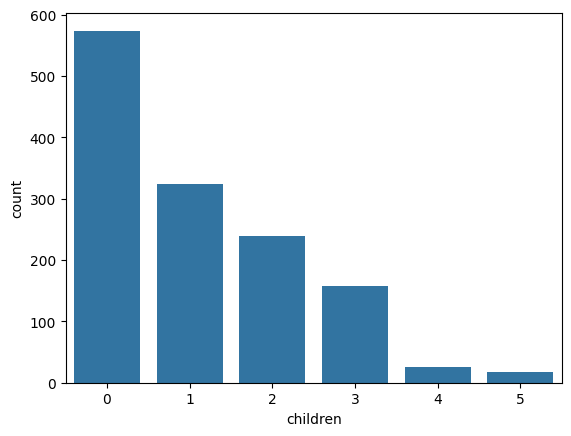

In [15]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

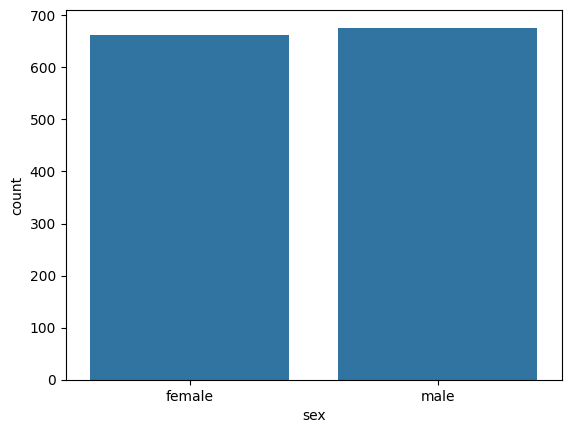

In [16]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

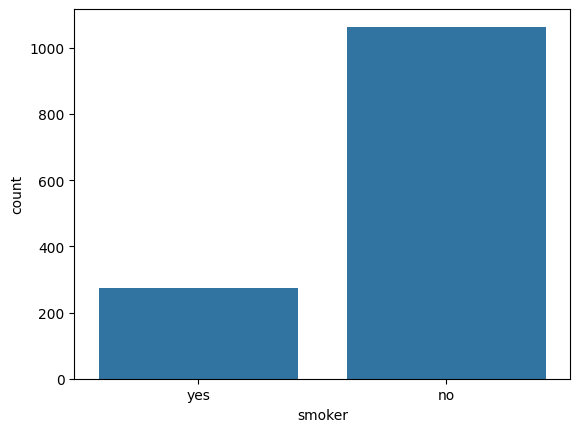

In [17]:
sns.countplot(x=df['smoker'])

In [18]:
#now we comapre inp variable with o/p variables

In [19]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


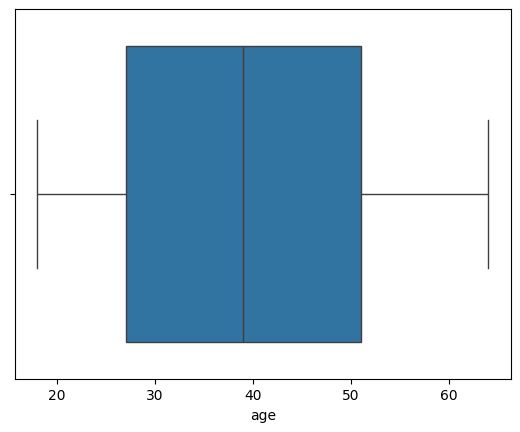

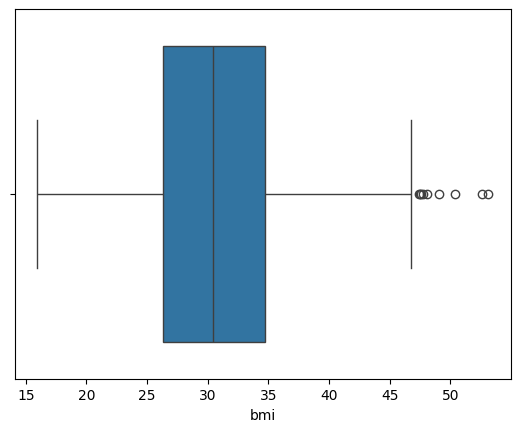

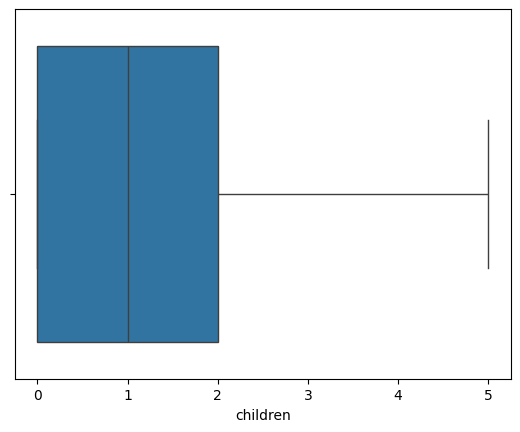

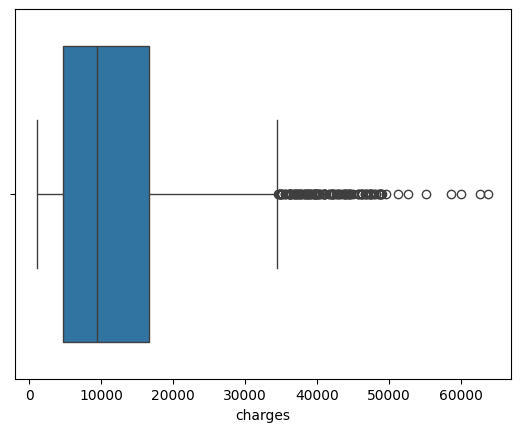

In [20]:
for col in numeric_cols:
  plt.figure()
  sns.boxplot(x=df[col])

<Axes: >

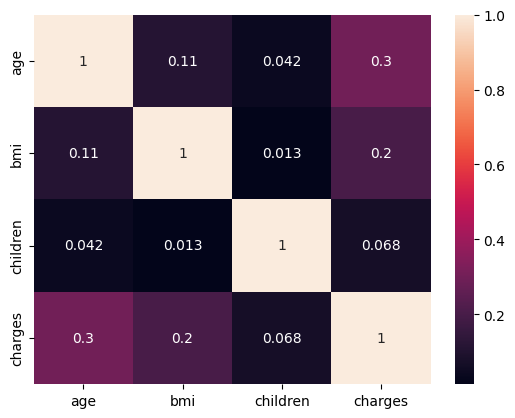

In [21]:
from __future__ import annotations
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [22]:
#data cleaning and preproccessing

In [23]:
#removing null values

In [24]:
df_cleaned=df.copy()

In [25]:
#remcoing duplicates

In [26]:
df_cleaned.drop_duplicates(inplace=True)

In [27]:
df_cleaned.shape

(1337, 7)

In [28]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [29]:
#we need to convert all in nums

In [30]:
df_cleaned['sex']= df_cleaned['sex'].map({"male":0 , "female":1})

In [31]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [32]:
df_cleaned['smoker']= df_cleaned['smoker'].map({"no":0 , "yes":1})

In [33]:
df_cleaned.head(2)


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.90,0,1,southwest,16884.9240
1,18,0,33.77,1,0,southeast,1725.5523


In [34]:
df_cleaned.rename(
    columns={"sex": "is_female", "smoker": "is_smoker"}, inplace=True
)

In [35]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [36]:
# we do one encoding-new colns

In [37]:
df_cleaned=pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [38]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [39]:
df_cleaned=df_cleaned.astype(int) #autoconvert true false into 0 and 1

In [40]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


<Axes: xlabel='bmi', ylabel='Count'>

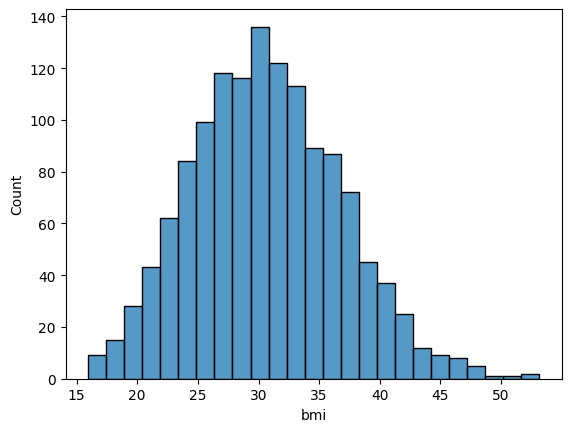

In [42]:
sns.histplot(df['bmi'])

In [44]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9, 29.9, float('inf')]
    ,labels=['underweight', 'normal', 'overweight', 'obese']
)

In [45]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [49]:
#df_cleaned=pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [50]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [51]:
df_cleaned=df_cleaned.astype(int) #autoconvert true false into 0 and 1


In [53]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [54]:
#now scaling

In [55]:
 df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [57]:
#we need to scale age and bm and children i as they are only ones not scaeed, we dont touch charges as it is output

In [60]:
from sklearn.preprocessing import StandardScaler
cols=['age', 'bmi', 'children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [61]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [62]:
#now feature extraxtion

In [70]:
correlation_matrix = df_cleaned.corr()
charges_correlation = correlation_matrix['charges'].sort_values(ascending=False)
display(charges_correlation)
#Pearson correlation between 'charges' and all other columns in  cleaned DataFrame.
#IF ANY FEATURE CORREALTION IS >.5 OR <-.5(THEY ARE HIGHLY CORRELATED)
#BETWEEN .2 AND .5 WE CAN CONSIDER
#.10 TO 0.20 IS NEGOTIABLE(SEE MODELS'S PERFORMACE USING THESE VARIABLES- IF ACC SCORES INCREASE(HIT AND TRY))


,charges
charges,1.000000
is_smoker,0.787234
age,0.298309
bmi_category_obese,0.200348
bmi,0.196236
region_southeast,0.073577
children,0.067390
region_northwest,-0.038695
region_southwest,-0.043637
is_female,-0.058046


### Chi-Square Test for Categorical Variables

To perform a Chi-square test, we need to convert the continuous 'charges' column into a categorical one. We'll create bins for 'charges' to categorize them into groups (e.g., low, medium, high).

In [71]:
# Bin 'charges' into categories
df_cleaned['charges_category'] = pd.qcut(df_cleaned['charges'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

display(df_cleaned[['charges', 'charges_category']].head())

,charges,charges_category
0,16884,Q4
1,1725,Q1
2,4449,Q1
3,21984,Q4
4,3866,Q1


Now, let's perform Chi-square tests between the newly created `charges_category` and other categorical features like `is_female`, `is_smoker`, `region_northwest`, `region_southeast`, `region_southwest`, `bmi_category_normal`, `bmi_category_overweight`, and `bmi_category_obese`.

In [72]:
from scipy.stats import chi2_contingency

categorical_cols = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

chi2_results = {}

print("Chi-square Test Results (charges_category vs. other categorical features):\n")
for col in categorical_cols:
    contingency_table = pd.crosstab(df_cleaned['charges_category'], df_cleaned[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results[col] = {'chi2': chi2, 'p_value': p_value}

    print(f"Feature: {col}")
    print(f"  Chi2 Statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Significant association (reject null hypothesis of independence)")
    else:
        print("  -> No significant association (fail to reject null hypothesis of independence)")
    print("\n")


Chi-square Test Results (charges_category vs. other categorical features):

Feature: is_female
  Chi2 Statistic: 10.2588
  P-value: 0.0165
  -> Significant association (reject null hypothesis of independence)


Feature: is_smoker
  Chi2 Statistic: 848.2192
  P-value: 0.0000
  -> Significant association (reject null hypothesis of independence)


Feature: region_northwest
  Chi2 Statistic: 1.1342
  P-value: 0.7688
  -> No significant association (fail to reject null hypothesis of independence)


Feature: region_southeast
  Chi2 Statistic: 15.9982
  P-value: 0.0011
  -> Significant association (reject null hypothesis of independence)


Feature: region_southwest
  Chi2 Statistic: 5.0919
  P-value: 0.1652
  -> No significant association (fail to reject null hypothesis of independence)


Feature: bmi_category_normal
  Chi2 Statistic: 3.7081
  P-value: 0.2948
  -> No significant association (fail to reject null hypothesis of independence)


Feature: bmi_category_overweight
  Chi2 Statistic: 4

### Explanation: Pearson Correlation vs. Chi-square Test

**Pearson Correlation (e.g., `charges` vs. `age`, `bmi`, `is_smoker`):**

*   **What it measures:** The strength and direction of a **linear relationship** between two **continuous** variables. The coefficient ranges from -1 to 1.
    *   `1`: Perfect positive linear relationship.
    *   `-1`: Perfect negative linear relationship.
    *   `0`: No linear relationship.
*   **How it helps:** It tells you how much one continuous variable tends to increase or decrease as another continuous variable increases. For example, a Pearson correlation of `0.787` between `charges` and `is_smoker` (after converting `is_smoker` to 0/1) means there's a strong positive linear association: as `is_smoker` goes from 0 to 1, `charges` tend to increase significantly.

**Chi-square Test of Independence (e.g., `charges_category` vs. `is_smoker`, `region`):**

*   **What it measures:** Whether there is a **statistically significant association** between two **categorical** variables. It doesn't tell you the strength or direction of the relationship directly, but whether they are independent or dependent.
*   **How it helps:** It helps determine if the observed frequencies of data points in different categories are significantly different from what would be expected if the two variables were independent. The output `p_value` is key:
    *   If `p_value < 0.05` (common significance level): You reject the null hypothesis of independence, meaning there is a statistically significant association between the two categorical variables. For example, if the p-value between `charges_category` and `is_smoker` is very low, it means being a smoker is significantly associated with belonging to a certain 'charges' category.
    *   If `p_value >= 0.05`: You fail to reject the null hypothesis, meaning there is no statistically significant association.

**Key Differences:**

1.  **Data Type:** Pearson is for continuous variables; Chi-square is for categorical variables.
2.  **Relationship Type:** Pearson measures linear relationships; Chi-square measures any association (not necessarily linear) between categories.
3.  **Output:** Pearson gives a coefficient indicating strength and direction; Chi-square gives a p-value indicating statistical significance of association.

```markdown
### Key Differences: Pearson Correlation vs. Chi-square Test

| Feature           | Pearson Correlation                                         | Chi-square Test                                      |
| :---------------- | :---------------------------------------------------------- | :--------------------------------------------------- |
| **Purpose**       | Measures linear relationship                                | Measures association/dependence between categories   |
| **Variable Types**| Two continuous variables (or one continuous, one binary)    | Two categorical variables                            |
| **Output**        | Coefficient (-1 to 1) indicating strength and direction     | P-value indicating statistical significance of association |
| **Interpretation**| Tells how much one variable changes as the other changes linearly. For binary variables, it shows the average difference in the continuous variable between groups. | Determines if the observed frequencies in categories are significantly different from expected if independent. |

**In the context of our analysis:**

*   **Pearson Correlation with `is_smoker` (0/1 encoded):** Quantifies how much `charges` linearly increase or decrease, on average, when `is_smoker` changes from 0 to 1 (i.e., comparing non-smokers to smokers).
*   **Chi-square Test with `is_smoker` and `charges_category`:** Assesses whether the *distribution* of `charges_category` (Q1, Q2, Q3, Q4) is significantly different between smokers and non-smokers. It tests if being a smoker is associated with a particular pattern across the charges categories.
```

In [75]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_obese']]

In [76]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
